In [1]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [55]:
sp = pd.read_csv('student_performance_dataset.csv')

In [56]:
print(sp.isnull().sum())

student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_sc

In [57]:
sp.dropna(inplace=True)

In [58]:
sp.dtypes

student_id                       int64
age                              int64
gender                          object
city_type                       object
study_hours_per_day            float64
deep_work_sessions               int64
assignment_completion_rate       int64
attendance_percentage            int64
social_media_hours             float64
doomscrolling_before_sleep       int64
notification_distractions        int64
ai_tool_usage_hours            float64
gaming_hours                   float64
stress_level                     int64
motivation_level                 int64
focus_score                    float64
procrastination_index            int64
mental_state                    object
sleep_hours                    float64
caffeine_intake                  int64
physical_activity_hours        float64
internet_quality                 int64
family_support                   int64
financial_stress                 int64
learning_style                  object
career_goal              

In [59]:
sp.columns

Index(['student_id', 'age', 'gender', 'city_type', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index',
       'mental_state', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'learning_style', 'career_goal',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score', 'performance_category'],
      dtype='object')

<Axes: ylabel='Frequency'>

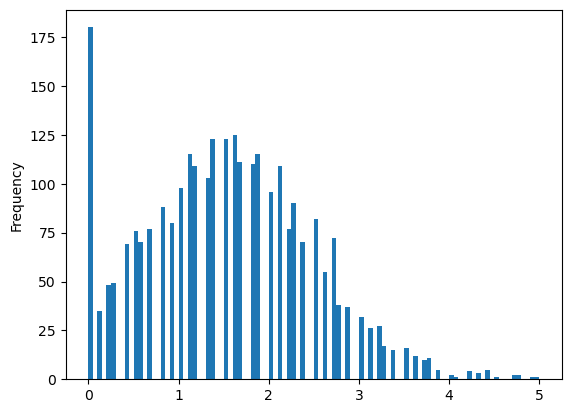

In [60]:
sp['ai_tool_usage_hours'].plot(kind='hist',bins=100)

<Axes: ylabel='Frequency'>

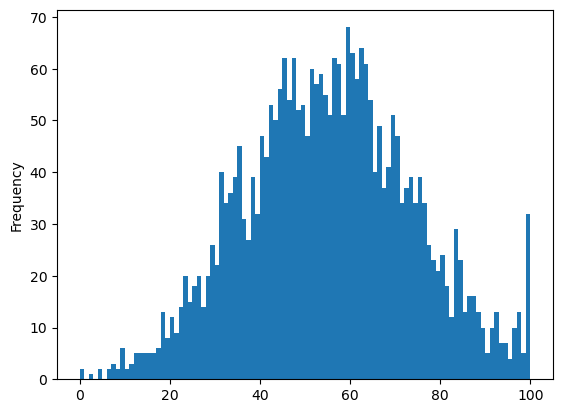

In [61]:
sp['final_exam_score'].plot(kind='hist',bins=100)

In [62]:
corr_matrix = sp[[ 'age', 'study_hours_per_day',
       'deep_work_sessions', 'assignment_completion_rate',
       'attendance_percentage', 'social_media_hours',
       'doomscrolling_before_sleep', 'notification_distractions',
       'ai_tool_usage_hours', 'gaming_hours', 'stress_level',
       'motivation_level', 'focus_score', 'procrastination_index', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress',
       'productivity_after_midnight', 'revision_efficiency', 'burnout_risk',
       'consistency_score', 'final_exam_score']].corr(method='spearman')

<Axes: >

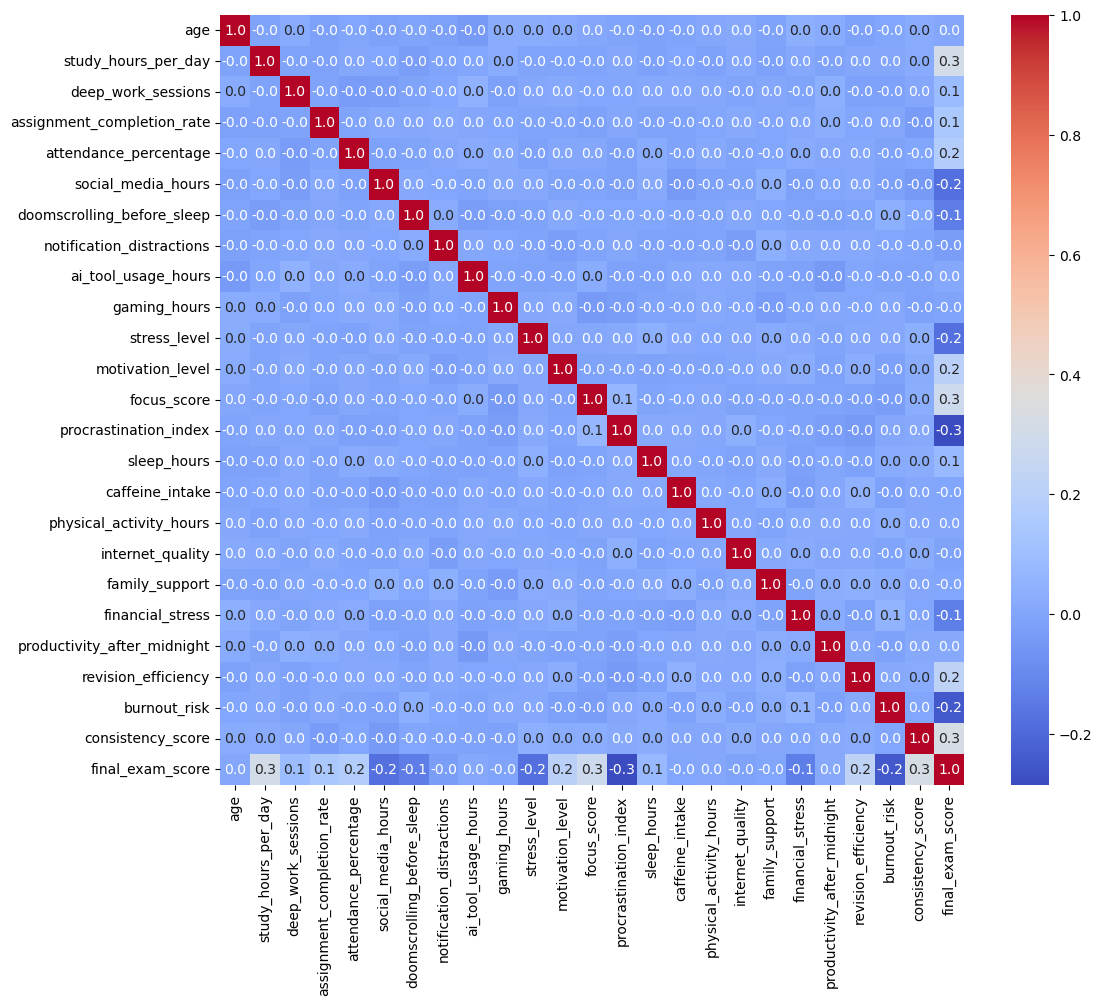

In [63]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.1f')

In [64]:
sp.drop(['learning_style','career_goal','mental_state'],axis=1,inplace=True)

In [65]:
df = sp.drop(['city_type'],axis=1).copy()

In [66]:
gender = lambda x: 1 if x == 'Male' else 0
df['gender'] = df['gender'].apply(gender)

In [68]:
df.drop(columns='performance_category',inplace=True)

In [69]:
q3 = df.quantile(0.75)
q1 = df.quantile(0.25)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

In [70]:
mask = ~(df < lower_bound) | (df > upper_bound)
df = df[mask.all(axis=1)]

In [71]:
def grade_filter(x):
    if x >= 90: return 3
    elif x>=80: return 2
    elif x>=70: return 1
    else: return 0
df['final_exam_score'] = df['final_exam_score'].apply(grade_filter)

In [72]:
# df = (df - df.min()) / (df.max()-df.min())
for col in df.columns:
    if col == 'final_exam_score': break
    df[col] = (df[col]-df[col].min()) / (df[col].max()-df[col].min())

In [73]:
columns = df.columns

In [74]:
for col,skew in enumerate(df.skew()):
    if skew>0.3:
        df[columns[col]] = np.log(df[columns[col]]+1)

In [75]:
########## model ###############
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [76]:
df = df.drop(columns='student_id')

In [81]:
df

,age,gender,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
0,0.750,0.0,0.325301,1.000000,1.000000,0.40,0.426966,0.0,0.894737,0.113329,...,0.571429,0.143101,0.000000,1.000000,0.555556,0.888889,0.000000,1.000000,0.222222,0.000000
1,0.500,0.0,0.409639,0.285714,0.100000,0.40,0.292135,1.0,0.771930,0.262364,...,0.714286,0.000000,0.333333,0.111111,0.555556,0.555556,1.000000,0.333333,0.555556,0.000000
2,0.125,0.0,0.457831,1.000000,0.233333,0.14,0.483146,1.0,0.675439,0.095310,...,0.571429,0.287682,0.888889,0.000000,0.888889,0.666667,0.888889,0.777778,0.000000,0.000000
3,0.500,1.0,0.578313,0.142857,0.633333,0.80,0.191011,0.0,0.192982,0.246860,...,0.285714,0.287682,0.000000,0.444444,1.000000,0.666667,0.666667,0.888889,1.000000,0.000000
4,0.250,0.0,0.433735,0.428571,1.000000,0.62,0.292135,0.0,0.026316,0.231112,...,0.714286,0.361790,0.888889,0.444444,0.555556,0.333333,1.000000,0.666667,0.888889,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.875,0.0,0.228916,0.000000,0.000000,0.66,0.112360,0.0,0.578947,0.431782,...,0.571429,0.268264,0.444444,1.000000,0.111111,0.888889,1.000000,0.666667,0.888889,0.000000
2996,0.500,0.0,0.566265,1.000000,0.900000,1.00,0.157303,0.0,0.956140,0.494696,...,0.285714,0.050010,0.222222,0.000000,1.000000,0.444444,0.222222,0.666667,0.888889,1.386294
2997,1.000,0.0,0.650602,0.285714,0.016667,0.72,0.606742,1.0,0.728070,0.000000,...,0.285714,0.120628,0.444444,0.666667,1.000000,0.555556,0.777778,1.000000,1.000000,0.000000
2998,0.250,1.0,0.409639,0.142857,0.866667,0.92,0.314607,1.0,0.780702,0.307485,...,0.000000,0.248461,0.666667,0.222222,1.000000,0.333333,0.666667,0.000000,0.333333,0.693147


In [77]:
x = df.iloc[:,0:25]
y = df.iloc[:,25].values

In [78]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=0)

In [79]:
xgb_train = xgb.DMatrix(x_train,y_train,enable_categorical=True)
xgb_test = xgb.DMatrix(x_test,y_test, enable_categorical=True)

In [80]:
params = {
    'objective': 'multi:softprob',   # or 'multi:softmax'
    'num_class': 4,                   # ← required for multiclass
    'max_depth': 5,
    'learning_rate': 0.01,
}

n = 15
model = xgb.train(params=params,dtrain=xgb_train,num_boost_round=n)

XGBoostError: [21:26:02] /Users/runner/miniforge3/conda-bld/xgboost-split_1779358231041/work/src/objective/multiclass_obj.cu:64: Check failed: valid: SoftmaxMultiClassObj: label must be discrete values in the range of [0, num_class).
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000176040208 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x0000000176345938 xgboost::obj::(anonymous namespace)::ValidateLabel(xgboost::Context const*, xgboost::MetaInfo const&, long long) + 720
  [bt] (2) 3   libxgboost.dylib                    0x00000001763448e4 xgboost::obj::SoftmaxMultiClassObj::InitEstimation(xgboost::MetaInfo const&, xgboost::linalg::Tensor<float, 1>*) const + 60
  [bt] (3) 4   libxgboost.dylib                    0x00000001762abc64 xgboost::LearnerImpl::UpdateOneIter(int, std::__1::shared_ptr<xgboost::DMatrix>) + 580
  [bt] (4) 5   libxgboost.dylib                    0x000000017606b3a4 XGBoosterUpdateOneIter + 

In [35]:
preds = model.predict(xgb_test)

In [36]:
preds=np.round(preds)

In [43]:
preds = np.argmax(preds,axis=1)

In [44]:
accuracy = accuracy_score(y_test,preds)
print('accuracy of the model is:', accuracy*100)

accuracy of the model is: 79.00355871886121


In [ ]:
tp,fp,tn,fn = 0,0,0,0
for i in range(len(preds)):
    if preds[i] == 1 and y_test[i] == 1:
        tp+=1
    elif preds[i] == 1 and y_test[i] == 0:
        fp+=1
    elif preds[i] == 0 and y_test[i] == 0:
        tn+=1
    elif preds[i] == 0 and y_test[i] == 1:
        fn+=1
    else:
        print('fuck')
